<center>

$\Huge \textbf{Universidad Nacional Autónoma de México}$  
$\Huge \textbf{Facultad de Ciencias}$  
<p align="center">
  <img src="https://www.icat.unam.mx/wp-content/uploads/2021/11/Copia-de-LogoUNAM.-Azul.-Fondo-transparente.png" alt="UNAM" width="200"/>
</p>

<hr style="height:3px; background-color:#0B6E4F; border:none;"/>


$\LARGE \textbf{Inteligencia Artificial}$  

$\Large \textit{Laboratorio 2.3}$  


\begin{array}{rl}
\textbf{Docente:} & Dra. Jessica Sarahi Méndez Rincón \\[6pt]
\textbf{Ayudante de laboratorio:} & Diego Eduardo Peña Villegas \\[6pt]
\textbf{Alumna:} & Erick Luis Juarez \\[6pt]
\textbf{Fecha de realización:} & 15/04/2026
\end{array}

</center>

# Bacterias

En un laboratorio se cultivan 2 tipos de bacteria (B1 y B2), los cuales necesitan 2 componentes químicos (X1 y X2) para sobrevivir en un frasco de cultivo. Los investigadores del laboratorio están interesados en determinar qué concentraciones de estos químicos son favorables para B1 y B2. Para esto realizaron varios cultivos con diferentes niveles de concentracidon de cada componente y se registrado qude bacteria sobrevivido en cada uno de ellos (los resultados de estas pruebas están almacenados en el archivo bacterias.csv), en el cual las primeras 2 columnas describen los niveles de concentracidon de X1 y X2 y la última indica si B1 (valor igual a 0) o B2 (valor igual a 1) sobrevivido. A partir de los datos propocionados entrena un clasificador bayesiano ingenuo que prediga qude tipo de bacteria sobrevivirá a una determinada concentracidon. Reporta el número de predicciones correctas y erróneas usando los mismos datos de entrenamiento. Analiza el desempeño del clasificador entrenado y explica los problemas que tiene con estos datos (pista: gráfica los datos para tener una idea de cdomo están distribuidos).

#Bibliotecas

In [1]:
# Importacion de librerias
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#Preparar los datos

In [2]:
# Importacion del archivo que se nos proporciono agregandole cabeceras que no contiene
names = ['X1', 'X2', 'R']
dataset = pd.read_csv('bacterias.csv',names=names)
X = dataset.iloc[:, [0, 1]].values
y = dataset.iloc[:, 2].values
print(y)

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.

 #ENTENDIMIENTO DE LOS DATOS

In [3]:
#Verifico la información contenida en el dataset
#Con head, podremos visualizar los primeros
dataset.head()

,X1,X2,R
0,8.070,14.488,0.0
1,8.684,12.804,0.0
2,7.083,11.816,0.0
3,8.330,12.583,0.0
4,12.606,10.710,0.0


In [4]:
#Con tail, podremos visualizar los últimos
dataset.tail()

,X1,X2,R
395,11.556,16.216,1.0
396,12.269,14.441,1.0
397,10.461,12.242,1.0
398,10.274,11.385,1.0
399,8.708,12.431,1.0


In [5]:
# Siempre resulta interesante echarle un vistazo a los datos.
# Podemos ver, por ejemplo, los 10 primeros registros.
print(dataset.head(10))

       X1      X2    R
0   8.070  14.488  0.0
1   8.684  12.804  0.0
2   7.083  11.816  0.0
3   8.330  12.583  0.0
4  12.606  10.710  0.0
5  13.643  11.172  0.0
6  10.668  12.355  0.0
7  11.084  10.714  0.0
8  13.265  10.512  0.0
9  10.988  12.016  0.0


In [6]:
#Verificamos el tipo de dato que contiene
dataset.dtypes


,0
X1,float64
X2,float64
R,float64


In [7]:
# descriptions
# La función describe nos ofrece una serie de valores
# como el número de registros,los valores máximos y mínimos,
# la media y algunos valores porcentuales.
dataset.describe(include="all")

,X1,X2,R
count,400.000000,400.000000,400.000000
mean,9.995945,12.483290,0.500000
std,1.844455,1.796707,0.500626
min,3.208000,6.846000,0.000000
25%,8.739250,11.319750,0.000000
50%,10.008000,12.430000,0.500000
75%,11.338000,13.616500,1.000000
max,14.590000,17.411000,1.000000


In [8]:
# class distribution
# La función class distribution nos indica cuántas
# instancias hay de cada caso
dataset.groupby('R').size()

,0
R,
0.0,200
1.0,200


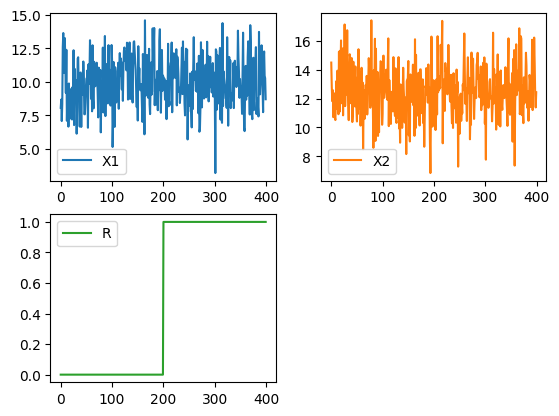

In [9]:
# Gráficas
dataset.plot(kind='line', subplots=True, layout=(2,2), sharex=False, sharey=False)
plt.show()

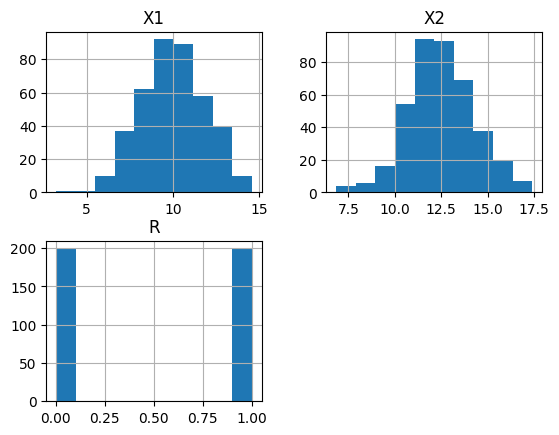

In [ ]:
dataset.hist()
plt.show()

IMPLEMENTACIÓN DE NAIVE BAYES

In [10]:
# Division de datos para entrenamientoy prueba
#Importamos la librería

from sklearn.model_selection import train_test_split

#Separo los datos de  "train" en entrenamiento y prueba para probar los algoritmos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [11]:
# Ajuste de escalas
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [12]:
#Definición del algoritmo a usar
# Creacion del modelo Naive Bayes
# y entrenamiento del mismo
from sklearn.naive_bayes import GaussianNB
classifier = GaussianNB()

#Entrenamiento

In [13]:
#Entrenamiento con el 80% que son con los 280 registros
classifier.fit(X_train, y_train)

GaussianNB()

#PREDICCIÓN

In [14]:
# Prediccion del conjunto de prueba de acuerdo al 20% para los entrenamientos 120 registros
y_pred = classifier.predict(X_test)

In [15]:
print(y_test)

[0. 1. 1. 0. 1. 0. 0. 1. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1.
 0. 1. 0. 0. 1. 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1.
 0. 1. 1. 0. 1. 0. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 0. 0. 0. 1. 0. 1.
 0. 0. 0. 0. 1. 1. 1. 1.]


In [16]:
print(y_pred)

[0. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 0. 1.
 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1. 1. 1. 1. 0. 0. 0.
 1. 1. 0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 0. 1. 0. 1. 1. 0. 1.
 0. 1. 1. 0. 1. 1. 1. 0.]


In [17]:
#Import scikit-learn metrics module for accuracy calculation
from sklearn import metrics

print("Exactitud:", metrics.accuracy_score(y_test, y_pred))

Exactitud: 0.525


In [18]:
# Matriz de confusion
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[17, 29],
       [ 9, 25]])

In [19]:
print(y_train)

[1. 0. 0. 0. 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 1. 1. 1. 0. 1. 0.
 1. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1.
 1. 0. 0. 1. 0. 1. 1. 0. 1. 0. 1. 0. 0. 0. 0. 0. 1. 0. 1. 1. 1. 0. 1. 0.
 1. 0. 1. 0. 1. 0. 0. 1. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 1. 1. 1. 1. 1.
 0. 0. 1. 1. 1. 0. 0. 1. 1. 1. 0. 0. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 1. 1.
 0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1. 1. 0. 0.
 1. 0. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 1. 0. 1. 0. 1. 1. 0. 0.
 0. 0. 0. 1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 1. 0. 0. 0. 1. 1.
 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 0. 1. 0.
 0. 0. 0. 0. 1. 1. 0. 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 0. 1. 1. 1. 0. 0. 0.
 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 1. 1. 1. 0. 0. 1. 1. 1.
 0. 0. 1. 0. 1. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 1. 1. 1. 0. 1. 1. 0. 0. 1.
 1. 0. 1. 0. 1. 0. 1. 0. 0. 1. 1. 0. 1. 0. 0. 1. 0. 0. 0. 1. 1. 1. 1. 0.
 1. 0. 1. 1. 0. 0. 0. 0.]


In [20]:
print ('Precisión del modelo:')
print(classifier.score(X_train,y_train))

Precisión del modelo:
0.546875


/tmp/ipykernel_19566/245070463.py:14: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(["r", "b"])(i), label = j)


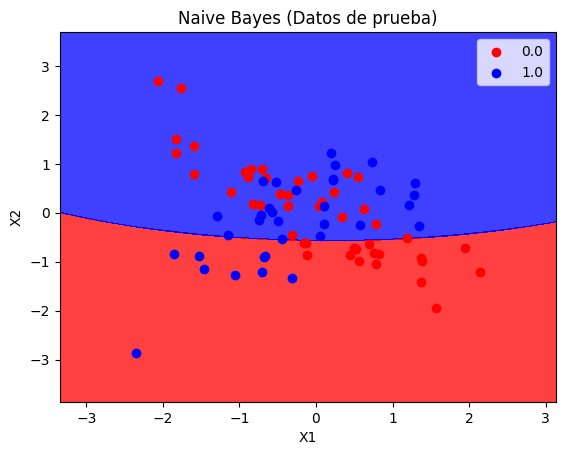

In [21]:
# Visualizacion de los datos de prueba
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(["r", "b"]))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())



for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(["r", "b"])(i), label = j)
plt.title('Naive Bayes (Datos de prueba)')
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.show()

In [22]:
#Realizar las predicciones en una validación de dataset
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

NB = GaussianNB()
NB.fit(X_train, y_train)
predictions = NB.predict(X_test)
print(accuracy_score(y_test, predictions))
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

0.525
[[17 29]
 [ 9 25]]
              precision    recall  f1-score   support

         0.0       0.65      0.37      0.47        46
         1.0       0.46      0.74      0.57        34

    accuracy                           0.53        80
   macro avg       0.56      0.55      0.52        80
weighted avg       0.57      0.53      0.51        80



C0,0=17 – Verdaderos Negativos, respuesta 0, predicción 0

C1,0=9 – Falsos Negativos, respuesta 1, predicción 0

C0,1=29 – Falsos Positivos, respuesta 0, predicción 1

C1,1=25 – Verdaderos Positivos, respuesta 1, predicción 1

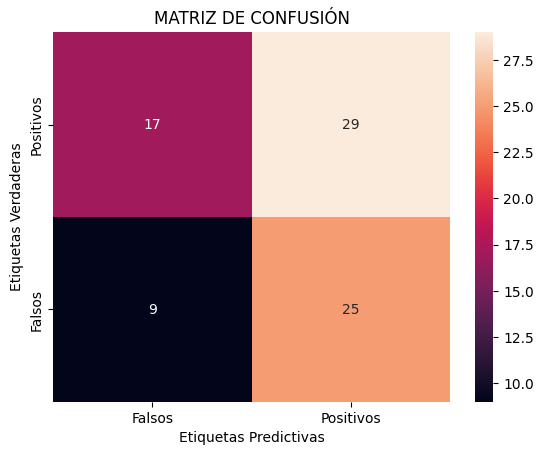

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

ax= plt.subplot()
sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells

# Etiquetas, Título and medidas
ax.set_xlabel('Etiquetas Predictivas');ax.set_ylabel('Etiquetas Verdaderas');
ax.set_title('MATRIZ DE CONFUSIÓN');
ax.xaxis.set_ticklabels(['Falsos', 'Positivos']); ax.yaxis.set_ticklabels(['Positivos', 'Falsos']);

# 1. Regresión Logística (Logistic Regression)
La regresión logística intentará encontrar un hiperplano (una línea, en este caso 2D) que separe las dos clases de bacterias.

¿Cómo funciona?: Calcula una combinación lineal de las entradas y le aplica la función sigmoide para obtener una probabilidad entre 0 y 1.

Limitación: Si las bacterias están distribuidas de forma circular o si una clase rodea a la otra (distribuciones no lineales), la Regresión Logística tendrá un desempeño pobre porque solo puede trazar fronteras rectas.

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# Entrenamiento
log_reg = LogisticRegression()
log_reg.fit(X, y)

# Predicciones sobre el mismo set(como pide el ejercicio)
y_pred_log = log_reg.predict(X)

print("Reporte Regresión Logística:")
print(classification_report(y, y_pred_log))



Reporte Regresión Logística:
              precision    recall  f1-score   support

         0.0       0.53      0.52      0.53       200
         1.0       0.53      0.54      0.53       200

    accuracy                           0.53       400
   macro avg       0.53      0.53      0.53       400
weighted avg       0.53      0.53      0.53       400



# 2. Máquinas de Vector de Soporte (SVM)
SVM es más robusto porque permite usar el Kernel Trick para encontrar fronteras de decisión complejas.

Kernel Lineal: Similar a la regresión logística.

Kernel RBF (Gaussiano): Crea fronteras curvas. Es muy probable que este sea el necesario para el dataset de bacterias si las concentraciones óptimas forman "nubes" o grupos cerrados.

In [25]:
from sklearn.svm import SVC
#Entrenamiento con un Kernel RBF para capturar no-linealidades
svm_model = SVC(kernel='rbf', gamma = 'auto')
svm_model.fit(X, y)

y_pred_svm = svm_model.predict(X)

print("Reporte SVM (RBF):")
print(classification_report(y, y_pred_svm))


Reporte SVM (RBF):
              precision    recall  f1-score   support

         0.0       0.79      0.75      0.77       200
         1.0       0.76      0.81      0.78       200

    accuracy                           0.78       400
   macro avg       0.78      0.78      0.78       400
weighted avg       0.78      0.78      0.78       400



#Visualización

In [31]:
def plot_decision_boundary(model, X, y, title):
    h = 0.03 #tamaño del paso en la malla
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha = 0.8)
    plt.scatter(X[:,0],X[:,1], c = y, edgecolors='k')
    plt.title(title)
    plt.show()


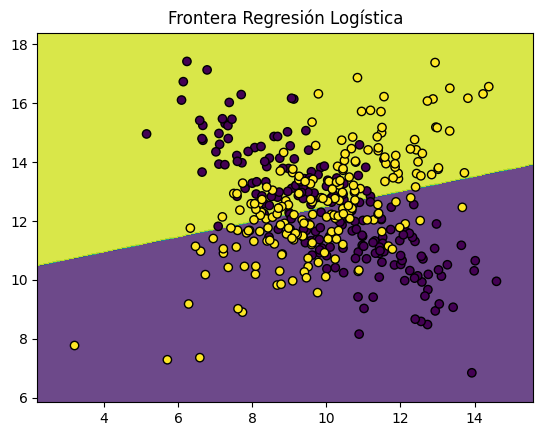

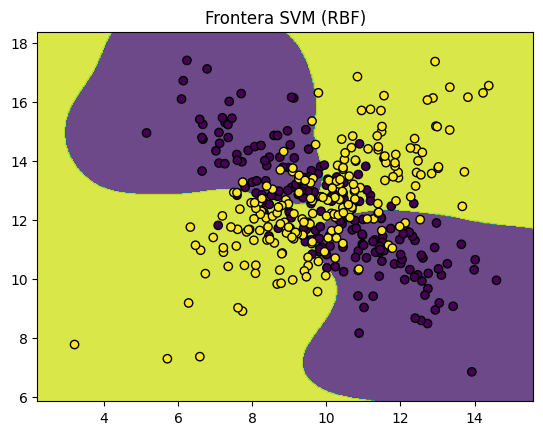

In [33]:
#Comparar visualmente
plot_decision_boundary(log_reg, X, y, "Frontera Regresión Logística")
plot_decision_boundary(svm_model, X, y, "Frontera SVM (RBF)")

#Conclusión

En conclusión, a pesar de contar con pocos datos, los modelos mostraron resultados similares en pruebas y predicciones; sin embargo, la precisión menor al 60% refleja un desempeño limitado. La matriz de confusión evidencia que, especialmente en medicina, es preferible un falso positivo a un falso negativo, por lo que es necesario mejorar los datos y el modelo para obtener resultados más confiables.

Bibliografía

<hr/>
<footer style="text-align:center; font-size:12px; color:gray;">
© 2026 UNAM Facultado de Ciencias – Todos los derechos reservados

</footer>